# 伊那中学校マインクエスト
## システム開発と少しAIの話

- 下記QRコードを読んでURLを開く

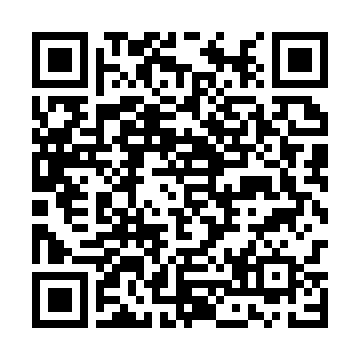

[https://colab.research.google.com/github/shuogawa/inachu/blob/main/lesson.ipynb](https://colab.research.google.com/github/shuogawa/inachu/blob/main/lesson.ipynb)


---
## 0. 自己紹介

- 伊那市に住んでいます。51歳です
- システム開発の仕事を25年くらいやっています
- 妻と娘がいます

---
## 1. まずはHelloWorld
今回は Pythonというプログラミング言語を利用します。

In [ ]:
print("伊那中のみなさん、こんにちは！")


---
## 2. 高速バスの予約システム

伊那 ⇄ 新宿のバスを予約するシステムを考えよう


---
# 3. システムの構成

システムは、だいたい3つの部品でできている。

`フロントエンド（画面）` → `バックエンド（サーバー）` → `データベース（データ）`

ボタンを押すと、右へ「お願い」が流れ、左へ「答え」が返ってくる。

#### ① データベース

「9/5 8時の便の 1A席 は、○○さんが予約ずみ」。
といったデータを記録する。

- データを記録する
- 話しかける言葉が **SQL**という言語

#### ② バックエンド

画面から「1Aを取りたい」と来たら、必要な確認を行い、保存する。

- 空いているか確かめる
- お金が払われたか確かめる
- ダメなら断る、OKならデータベースに保存

#### ③ フロントエンド

座席表を並べて、押されたらバックエンドにお願いを送る係。

- 見やすく出すのが仕事

> この3つが毎回やり取りしている。

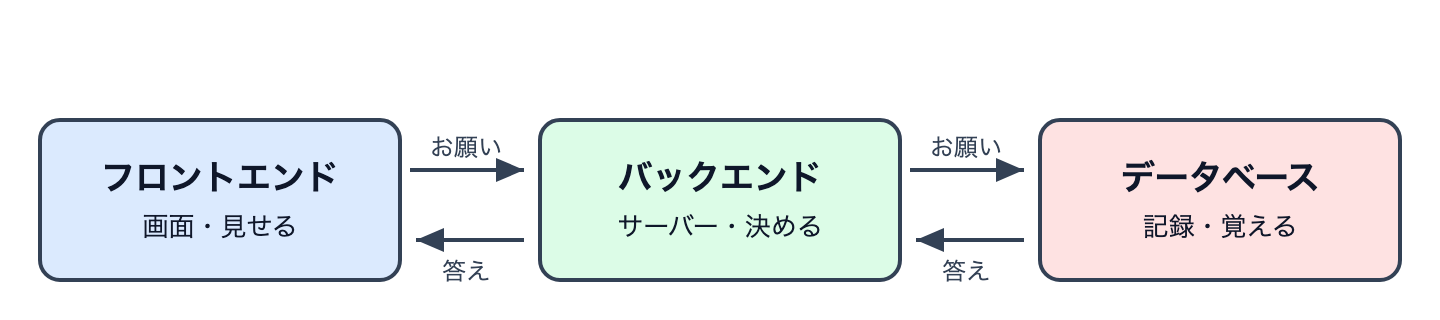


---
# 4. データベース実習

### 4-1. 準備：データベースを起動する

1〜2分かかります。押したら待っててください。


In [ ]:
import subprocess

def _ok(args):
    """その接続方法でMySQLに繋がるか試す。"""
    try:
        return subprocess.run(["mysql", *args, "-u", "root", "-e", "SELECT 1"],
                              capture_output=True).returncode == 0
    except FileNotFoundError:
        return False

# ソケット（Colab）か TCP（手元の docker compose）か、繋がるほうを使う
MYSQL = next((a for a in ([], ["-h", "127.0.0.1"]) if _ok(a)), None)

if MYSQL is None:   # MySQLがまだ無い = Colab。ここで入れる（1〜2分）
    !apt-get -qq update > /dev/null && apt-get -qq install -y mysql-server > /dev/null
    !service mysql start
    MYSQL = []

subprocess.run(["mysql", *MYSQL, "-u", "root", "-e", "CREATE DATABASE IF NOT EXISTS bus"])

def sql(q):
    """SQLを実行して結果を表示する。以降ぜんぶこれを使う。"""
    r = subprocess.run(["mysql", *MYSQL, "-u", "root", "--table", "bus"],
                       input=q, capture_output=True, text=True)
    print(r.stdout or r.stderr)

print("準備OK", "（ソケット接続）" if not MYSQL else "（127.0.0.1 接続）")


### 4-2. テーブルを作る（CREATE TABLE）

データベースは「2次元の表」でできている。この表のことを **テーブル** と呼ぶ。
バス予約に必要な表は4つ。

| テーブル | なにが入っているか |
|---|---|
| `car` | バスの車両。「伊那号 1号車」 |
| `car_chairs` | その車両のイス。1A, 1B ... 毎日変わらない |
| `car_plan` | 運行の予定。9/5 8:00 伊那→新宿 |
| `car_plan_chairs` | **便ごとのイス。ここに予約が入る** |

**なぜイスの表が2つあるの？**
イスは毎日同じ場所にある。でも「誰が座るか」は便ごとに違う。
だから分ける。これを考えるのが *設計* という仕事。


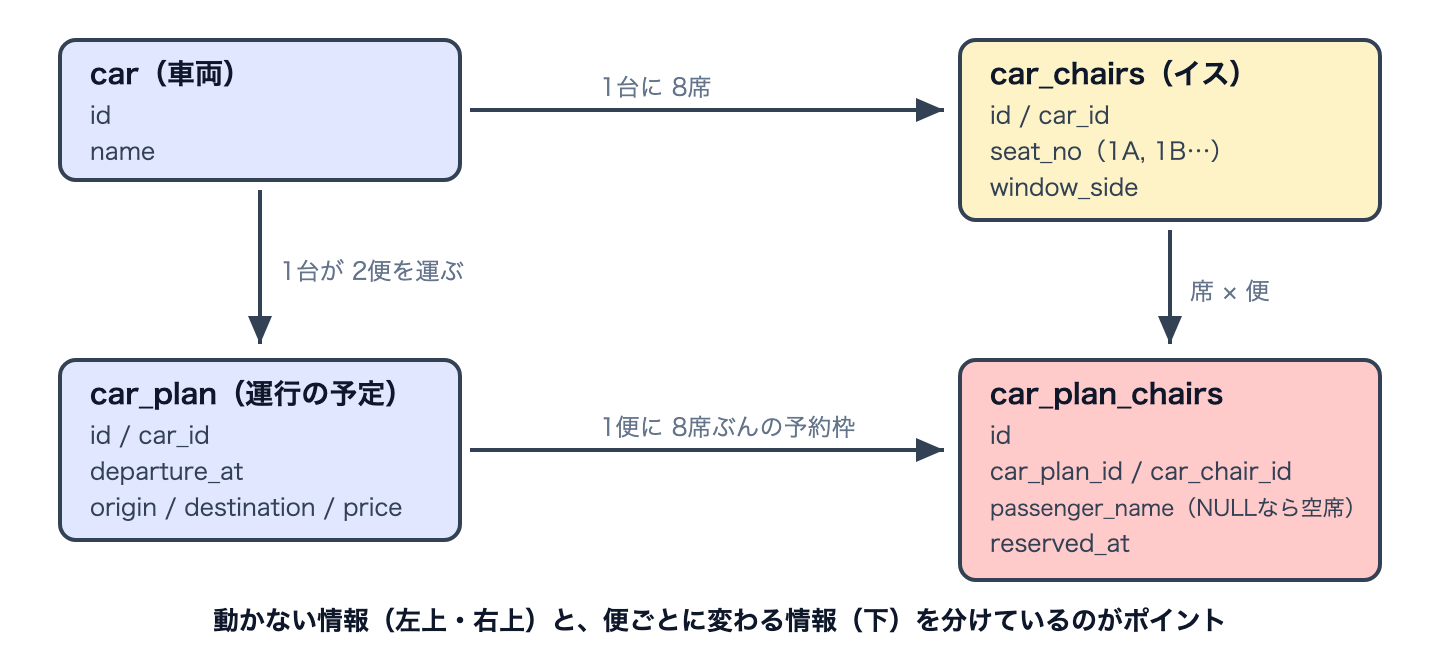


In [ ]:
sql("""
DROP TABLE IF EXISTS car_plan_chairs, car_plan, car_chairs, car;

-- 1) バスの車両
CREATE TABLE car (
  id   INT AUTO_INCREMENT PRIMARY KEY,
  name VARCHAR(50) NOT NULL COMMENT '車両の呼び名'
);

-- 2) その車両のイス（動かない情報）
CREATE TABLE car_chairs (
  id          INT AUTO_INCREMENT PRIMARY KEY,
  car_id      INT         NOT NULL,
  seat_no     VARCHAR(5)  NOT NULL COMMENT '1A, 1B ...',
  window_side BOOLEAN     NOT NULL COMMENT '窓側なら true',
  UNIQUE (car_id, seat_no),
  FOREIGN KEY (car_id) REFERENCES car(id)
);

-- 3) 運行の予定（いつ・どこからどこへ・どの車両で）
CREATE TABLE car_plan (
  id           INT AUTO_INCREMENT PRIMARY KEY,
  car_id       INT         NOT NULL,
  departure_at DATETIME    NOT NULL,
  origin       VARCHAR(50) NOT NULL,
  destination  VARCHAR(50) NOT NULL,
  price        INT         NOT NULL,
  FOREIGN KEY (car_id) REFERENCES car(id)
);

-- 4) 便ごとのイス = 予約が入る場所
CREATE TABLE car_plan_chairs (
  id             INT AUTO_INCREMENT PRIMARY KEY,
  car_plan_id    INT         NOT NULL,
  car_chair_id   INT         NOT NULL,
  passenger_name VARCHAR(50) DEFAULT NULL COMMENT 'NULL なら空席',
  reserved_at    DATETIME    DEFAULT NULL,
  UNIQUE (car_plan_id, car_chair_id),  -- 同じ便の同じ席は1行だけ
  FOREIGN KEY (car_plan_id)  REFERENCES car_plan(id),
  FOREIGN KEY (car_chair_id) REFERENCES car_chairs(id)
);

SHOW TABLES;
""")


### 4-3. データを入れる（INSERT）

表ができた。まだ空っぽなので、中身を入れる。


In [ ]:
sql("""
DELETE FROM car_plan_chairs;
DELETE FROM car_plan;
DELETE FROM car_chairs;
DELETE FROM car;

-- 消したあとも id の続き番号は残るので、1 に戻しておく（何度でもやり直せるように）
ALTER TABLE car             AUTO_INCREMENT = 1;
ALTER TABLE car_chairs      AUTO_INCREMENT = 1;
ALTER TABLE car_plan        AUTO_INCREMENT = 1;
ALTER TABLE car_plan_chairs AUTO_INCREMENT = 1;

INSERT INTO car (name) VALUES ('伊那号 1号車'), ('伊那号 2号車');

INSERT INTO car_chairs (car_id, seat_no, window_side) VALUES
(1,'1A',true),(1,'1B',false),(1,'1C',false),(1,'1D',true),
(1,'2A',true),(1,'2B',false),(1,'2C',false),(1,'2D',true);

INSERT INTO car_plan (car_id, departure_at, origin, destination, price) VALUES
(1,'2026-09-05 08:00:00','伊那','新宿',3800),
(1,'2026-09-05 14:00:00','新宿','伊那',3800);

INSERT INTO car_plan_chairs (car_plan_id, car_chair_id)
SELECT p.id, c.id FROM car_plan p JOIN car_chairs c ON c.car_id = p.car_id;

-- 2人ぶんの予約が入った状態にする
UPDATE car_plan_chairs SET passenger_name='小川', reserved_at=NOW()
WHERE car_plan_id=1 AND car_chair_id=(SELECT id FROM car_chairs WHERE car_id=1 AND seat_no='1A');
UPDATE car_plan_chairs SET passenger_name='田中', reserved_at=NOW()
WHERE car_plan_id=1 AND car_chair_id=(SELECT id FROM car_chairs WHERE car_id=1 AND seat_no='2D');

SELECT * FROM car;
SELECT * FROM car_chairs;
SELECT * FROM car_plan;
SELECT * FROM car_plan_chairs;
""")


### 4-4. 調べる（SELECT）

`SELECT` は「知りたいことを聞く」命令。

**どんな便がある？**


In [ ]:
sql("""
SELECT p.id, c.name, p.departure_at, p.origin, p.destination, p.price
  FROM car_plan p
  JOIN car c ON c.id = p.car_id
 ORDER BY p.departure_at;
""")


### 4-5. 8時の便の座席表（予約サイトのあの画面）


In [ ]:
sql("""
SELECT ch.seat_no,
       IF(ch.window_side,'窓側','通路側') AS `席`,
       IFNULL(pc.passenger_name,'空席')  AS `状況`
  FROM car_plan_chairs pc
  JOIN car_chairs ch ON ch.id = pc.car_chair_id
 WHERE pc.car_plan_id = 1
 ORDER BY ch.seat_no;
""")


### 4-6. 「残り○席」はこう数えている


In [ ]:
sql("""
SELECT p.departure_at, p.origin, p.destination,
       COUNT(*)                          AS `全席`,
       SUM(pc.passenger_name IS NULL)     AS `空席`
  FROM car_plan p
  JOIN car_plan_chairs pc ON pc.car_plan_id = p.id
 GROUP BY p.id
 ORDER BY p.departure_at;
""")


### 4-7. 「窓側の空いてる席だけ見せて」

人間が全部の席を目で見て探す代わりに、1行聞けば出てくる。
これが何万席あっても同じ速さで出る。だからシステムを作る意味がある。


In [ ]:
sql("""
SELECT p.departure_at, ch.seat_no
  FROM car_plan_chairs pc
  JOIN car_chairs ch ON ch.id = pc.car_chair_id
  JOIN car_plan   p  ON p.id  = pc.car_plan_id
 WHERE pc.passenger_name IS NULL
   AND ch.window_side = true
 ORDER BY p.departure_at, ch.seat_no;
""")


### 4-8. わざとエラーを出してみる

最初の質問に戻る。**同じ席が2人に売れたら？**

答え: 売れない。データベースが拒否する。やってみよう。


In [ ]:
# 8時の便の 1A席 を、もう一度作ろうとする
sql("""
INSERT INTO car_plan_chairs (car_plan_id, car_chair_id) VALUES (1, 1);
""")

# => ERROR 1062 Duplicate entry ... と出るのが「正しい」動き


さっき書いた `UNIQUE (car_plan_id, car_chair_id)` の1行が効いている。

---
# 5. バックエンド実習

バックエンドはフロントエンドからの要求を確認。保存、データを返却する。

「1Bを取りたい」と来たときに、
1. そんな席ある？
2. もう誰か座ってない？
3. OKならデータベースに書く / ダメなら断る

これを Python で書いてみる。まずは結果を Python で受け取る道具から。


In [ ]:
def q(query):
    """SQLを実行して、結果を Python のリスト（表）で受け取る。"""
    r = subprocess.run(["mysql", *MYSQL, "-u", "root", "-N", "-B", "bus"],
                       input=query, capture_output=True, text=True)
    if r.returncode:
        raise RuntimeError(r.stderr.strip())
    return [line.split("\t") for line in r.stdout.splitlines()]

q("SELECT seat_no, window_side FROM car_chairs WHERE car_id = 1")


### 5-1. 予約のルールを書く

さっきの1〜3を、そのまま関数にする。**これがバックエンドの正体**。


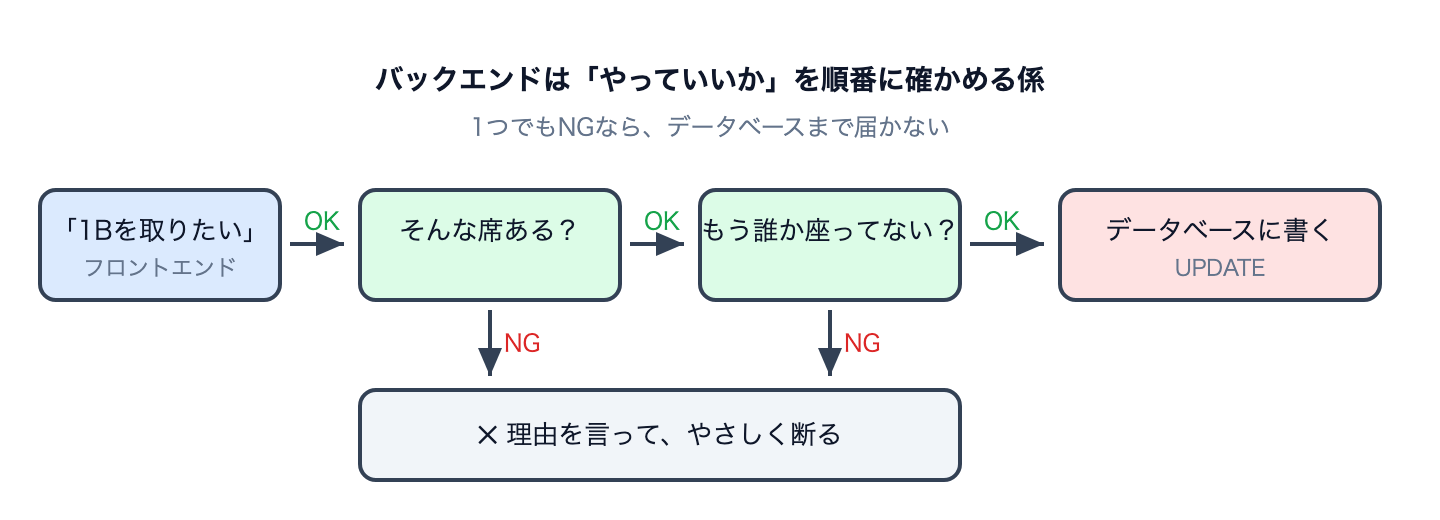


In [ ]:
def reserve(plan_id, seat_no, name):
    """予約していいか判断して、OKならデータベースに書く。"""
    name = name.replace("'", "")   # 本物の現場では「プレースホルダ」を使う。今日は簡単に

    found = q(f"""
      SELECT pc.id, pc.passenger_name
        FROM car_plan_chairs pc
        JOIN car_chairs ch ON ch.id = pc.car_chair_id
       WHERE pc.car_plan_id = {plan_id} AND ch.seat_no = '{seat_no}'
    """)

    if not found:                                   # 1. そんな席ある？
        return f"✕ {seat_no} という席はありません"

    row_id, who = found[0]
    if who != "NULL":                               # 2. もう誰か座ってない？
        return f"✕ {seat_no} は {who} さんが予約ずみです"

    q(f"UPDATE car_plan_chairs SET passenger_name='{name}', reserved_at=NOW() WHERE id={row_id}")
    return f"○ {seat_no} を {name} さんで予約しました"   # 3. OK


### 5-2. 動かしてみる

3回呼んでみる。2回目と3回目は**断られるのが正しい**。


In [ ]:
print(reserve(1, "1B", "きみの名前"))
print(reserve(1, "1B", "あとから来た人"))   # 同じ席をもう一度 → 断られる
print(reserve(1, "9Z", "だれか"))          # 無い席 → 断られる


---
# 6. フロントエンド実習

最後は、人が見るところ。フロントエンドの仕事は2つだけ。

1. 奥からもらったデータを、**見やすく並べる**
2. 押されたら、バックエンドに**お願いを送る**

通常は HTML Javascriptという言語を利用するが今回はPythonで動かします。

### 6-1. まず表示する


In [ ]:
from IPython.display import HTML, display

def seat_map(plan_id=1):
    """座席表を絵にする。判断はしない、ただ並べるだけ。"""
    rows = q(f"""
      SELECT ch.seat_no, IFNULL(pc.passenger_name, '')
        FROM car_plan_chairs pc
        JOIN car_chairs ch ON ch.id = pc.car_chair_id
       WHERE pc.car_plan_id = {plan_id}
       ORDER BY ch.seat_no
    """)
    boxes = "".join(
        f'<div style="padding:12px;border-radius:6px;text-align:center;color:#1a1a1a;'
        f'background:{"#f8bbd0" if who else "#c8e6c9"}">{seat}<br><small>{who or "空席"}</small></div>'
        for seat, who in rows)
    return HTML(f'<div style="display:grid;grid-template-columns:repeat(4,90px);gap:6px">{boxes}</div>')

display(seat_map())


緑が空席、ピンクが予約ずみ。
**この色は画面が勝手に決めているのではなく、データベースの中身そのもの。**

### 6-2. 押せるようにする

ボタンを押すと、5章の `reserve()` が呼ばれ、その中でデータベースが書き換わる。
`フロントエンド → バックエンド → データベース` が、1回のクリックで全部つながる。


In [ ]:
import ipywidgets as widgets

name_box = widgets.Text(value="あなたの名前", description="なまえ")
log = widgets.Output()

def make_button(seat_no, who):
    b = widgets.Button(description=f"{seat_no} {who or '空席'}",
                       button_style="danger" if who else "success",
                       disabled=bool(who))
    def on_click(_):
        msg = reserve(1, seat_no, name_box.value)   # ← 画面は「お願い」するだけ
        with log:
            log.clear_output()
            print(msg)
        if msg.startswith("○"):                     # OKだった時だけ見た目を変える
            b.description = f"{seat_no} {name_box.value}"
            b.button_style, b.disabled = "danger", True
    b.on_click(on_click)
    return b

seats = q("""
  SELECT ch.seat_no, IFNULL(pc.passenger_name, '')
    FROM car_plan_chairs pc JOIN car_chairs ch ON ch.id = pc.car_chair_id
   WHERE pc.car_plan_id = 1 ORDER BY ch.seat_no
""")
display(name_box,
        widgets.GridBox([make_button(s, w) for s, w in seats],
                        layout=widgets.Layout(grid_template_columns="repeat(4, 130px)")),
        log)


---
# 7. AI

## 7-1. ChatからAgentへ

少し前のAIは **チャット** だった。質問すると、答えが返ってくる。それだけ。
書くのも、動かすのも、直すのも人間。

今のAIは **エージェント** になった。
「なになにを作って」と頼むと、AIが自分でパソコンを操作し、最後までやりきる。

**コンピューターの中だけで完結する仕事**
プログラマー　音楽家　映像クリエーター　などなど　みんな衝撃を受けている

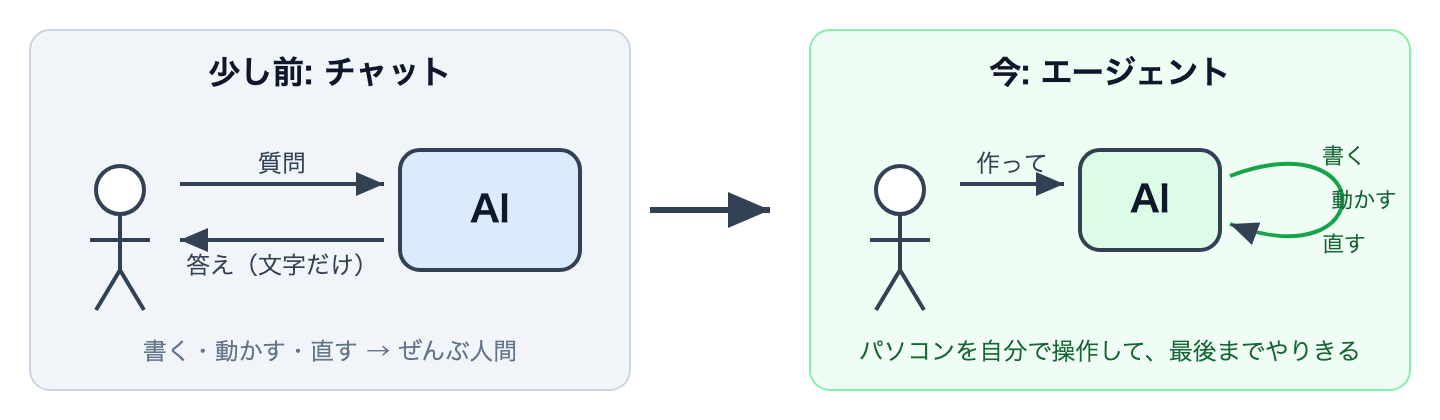

## 7-2. システム開発とCoding Agent

**Coding Agent** = コードを書くことに特化したエージェント。
今の現場では、エンジニアはこれと2人で組んで仕事をしている。

- 昔: エンジニアが1行ずつ手で打つ
- 今: **AIが下書きし、人が決めて、人が確かめる**

これは未来の話じゃなくて、今の現場の話。この一年で変わった、

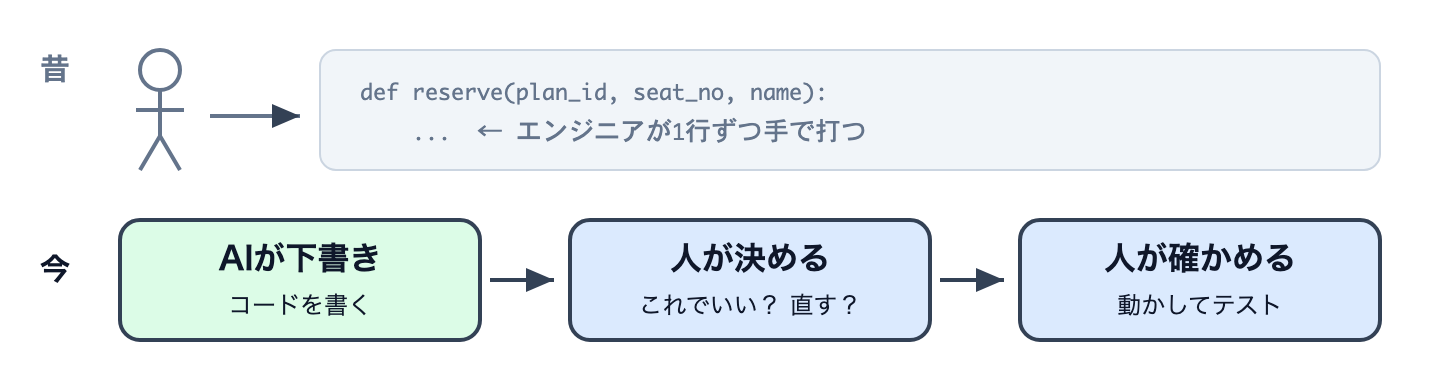

## 7-３.　みんなの時代の働き方

AIはブームでなく、今後　言葉を話し　人の様に振る舞う様になる　これは確定した未来。

みんなが仕事する頃には、**最初からAIが隣にいる世代**。

なので、みなさんは、AIといったテクノロジーに軸足１個をおきつつ、それに、自分のやりたい領域を掛け算する、そんな働き方になると思う。

自分のやりたい領域を探し続けて下さい。とても楽しい未来が待っているはず。


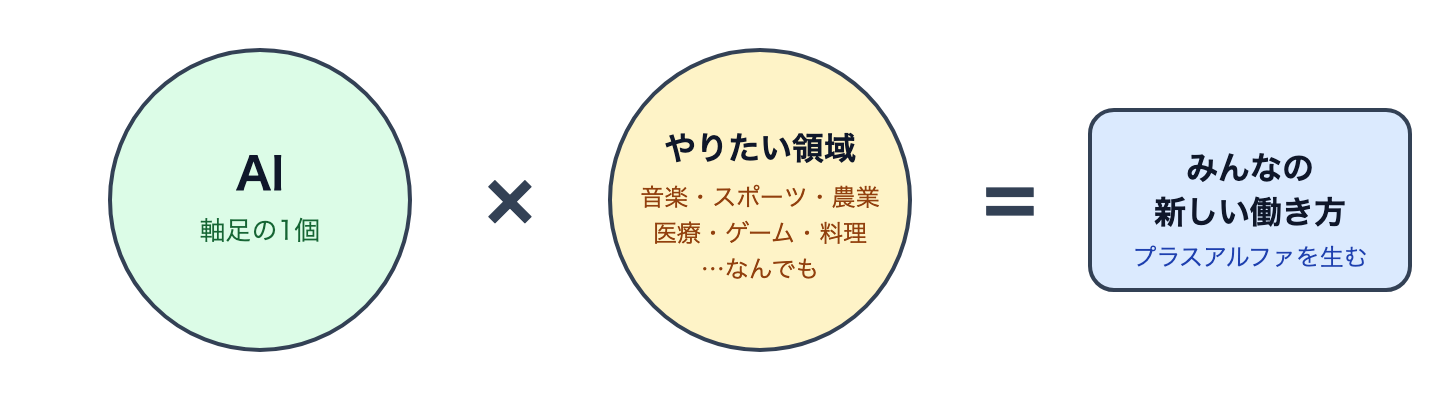

## 7-4. 最後に仕事とは

**そもそも仕事って何だろう。**

親に育ててもらい、社会に出て、まずは自分を養い、部下を持ち、家族を持ち、今度は **自分が養う側にまわる** それの繰り返し。

50歳にもなると、自分の仕事が誰かの役に立ち、お金としてまわっていれば、それで十分と思えてくる。

迷った時は、自分の行動が、誰かの為になる、その羅針盤を持っていれば大丈夫。




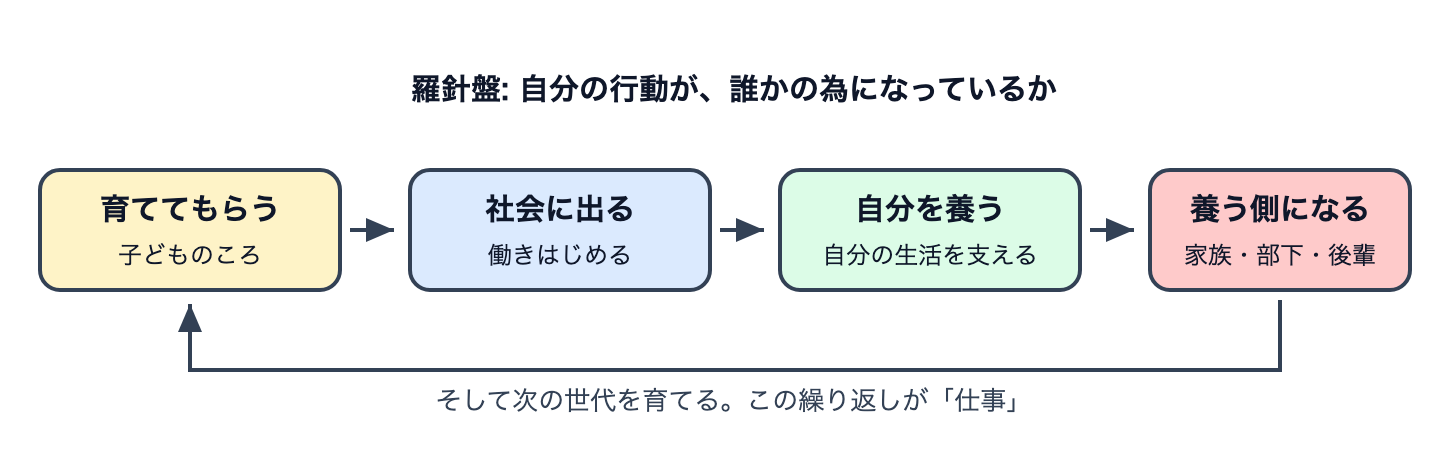

---
# 8. ご質問

質問どうぞ。
